In [36]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures



In [37]:
!pip install xgboost

In [38]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Utilities
import joblib
import warnings
warnings.filterwarnings("ignore")

In [39]:
df_train=pd.read_csv(r"C:\Users\archa\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\A57CAC52B356AF3E9FB136DDFCC52EF31B585694\transfers\2026-14\house-prices-advanced-regression-techniques (2)\train.csv")

In [40]:
df_test=pd.read_csv(r"C:\Users\archa\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\A57CAC52B356AF3E9FB136DDFCC52EF31B585694\transfers\2026-14\house-prices-advanced-regression-techniques (2)\test.csv")

In [41]:
df_train=df_train.drop(columns=["Id"],axis=1)
df_test=df_test.drop(columns=["Id"],axis=1)

In [42]:
df_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [43]:
df_train.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [44]:
df_test.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [45]:
df_train.shape

(1460, 80)

In [46]:
df_test.shape

(1459, 79)

In [47]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [48]:
df_train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [49]:
df_train.duplicated().sum()

np.int64(0)

In [50]:
# Separate numerical and categorical data
#training_data
df_train_num = df_train.select_dtypes(include=[np.number])
df_train_cat = df_train.select_dtypes(include=['object'])

#testing_data
df_test_num = df_test.select_dtypes(include=[np.number])
df_test_cat = df_test.select_dtypes(include=['object'])

print("Numeric features:", df_train_num.shape[1])
print("Categorical features:", df_train_cat.shape[1])


Numeric features: 37
Categorical features: 43


In [51]:
df_train_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


In [52]:
df_train_num.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [53]:
df_train_cat.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [54]:
print("Missing values in training data:")
print(df_train.isnull().sum().sort_values(ascending=False).head(20))

print("\nMissing values in test data:")
print(df_test.isnull().sum().sort_values(ascending=False).head(20))


Missing values in training data:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageType        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtFinType1      37
BsmtCond          37
MasVnrArea         8
Electrical         1
BldgType           0
dtype: int64

Missing values in test data:
PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageCond        78
GarageFinish      78
GarageYrBlt       78
GarageQual        78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType2      42
BsmtFinType1      42
MasVnrArea        15
MSZoning           4
BsmtHalfBath       2
dtype: int64


In [55]:
#outlier treatment
def detect_and_treat_outliers(df_numeric, method='iqr', factor=1.5):
    """
    Detect and treat outliers using IQR method
    """
    df_treated = df_numeric.copy()
    outlier_info = {}
    
    for column in df_numeric.columns:
        if column == 'SalePrice':  # Don't treat outliers in target variable
            continue
            
        Q1 = df_numeric[column].quantile(0.25)
        Q3 = df_numeric[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        
        # Count outliers
        outliers = ((df_numeric[column] < lower_bound) | (df_numeric[column] > upper_bound))
        outlier_count = outliers.sum()
        
        if outlier_count > 0:
            outlier_info[column] = outlier_count
            # Cap outliers instead of removing them
            df_treated[column] = df_treated[column].clip(lower=lower_bound, upper=upper_bound)
    
    print(f"Outliers detected and treated in {len(outlier_info)} features:")
    for col, count in outlier_info.items():
        print(f"  {col}: {count} outliers")
    
    return df_treated

In [56]:
df_train_num_treated = detect_and_treat_outliers(df_train_num)
df_test_num_treated = detect_and_treat_outliers(df_test_num)

Outliers detected and treated in 30 features:
  MSSubClass: 103 outliers
  LotFrontage: 88 outliers
  LotArea: 69 outliers
  OverallQual: 2 outliers
  OverallCond: 125 outliers
  YearBuilt: 7 outliers
  MasVnrArea: 96 outliers
  BsmtFinSF1: 7 outliers
  BsmtFinSF2: 167 outliers
  BsmtUnfSF: 29 outliers
  TotalBsmtSF: 61 outliers
  1stFlrSF: 20 outliers
  2ndFlrSF: 2 outliers
  LowQualFinSF: 26 outliers
  GrLivArea: 31 outliers
  BsmtFullBath: 1 outliers
  BsmtHalfBath: 82 outliers
  BedroomAbvGr: 35 outliers
  KitchenAbvGr: 68 outliers
  TotRmsAbvGrd: 30 outliers
  Fireplaces: 5 outliers
  GarageCars: 5 outliers
  GarageArea: 21 outliers
  WoodDeckSF: 32 outliers
  OpenPorchSF: 77 outliers
  EnclosedPorch: 208 outliers
  3SsnPorch: 24 outliers
  ScreenPorch: 116 outliers
  PoolArea: 7 outliers
  MiscVal: 52 outliers
Outliers detected and treated in 32 features:
  MSSubClass: 104 outliers
  LotFrontage: 100 outliers
  LotArea: 60 outliers
  OverallQual: 2 outliers
  OverallCond: 127 out

In [57]:
# Fill numeric columns with median
df_train_num = df_train_num.fillna(df_train_num.median())
df_test_num = df_test_num.fillna(df_test_num.median())

# Fill categorical columns with mode
df_train_cat = df_train_cat.fillna(df_train_cat.mode().iloc[0])
df_test_cat = df_test_cat.fillna(df_test_cat.mode().iloc[0])

In [58]:
combined_cat = pd.concat([df_train_cat, df_test_cat], axis=0)
combined_encoded = pd.get_dummies(combined_cat, drop_first=True)

df_train_cat_encoded = combined_encoded.iloc[:len(df_train)]
df_test_cat_encoded = combined_encoded.iloc[len(df_train):]

print("Encoded categorical features:", df_train_cat_encoded.shape[1])

Encoded categorical features: 208


In [59]:
# Separate the target variable before scaling
target = "SalePrice"

# Drop SalePrice from numerical features before scaling
train_num_features = df_train_num.drop(columns=[target])

# Scale numerical features
scaler = StandardScaler()

df_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(train_num_features),
    columns=train_num_features.columns
)

df_test_num_scaled = pd.DataFrame(
    scaler.transform(df_test_num),
    columns=df_test_num.columns
)

print("Scaled Train Shape:", df_train_num_scaled.shape)
print("Scaled Test Shape:", df_test_num_scaled.shape)


Scaled Train Shape: (1460, 36)
Scaled Test Shape: (1459, 36)


In [60]:
# Combine scaled numerical features with encoded categorical features
X = pd.concat([df_train_num_scaled, df_train_cat_encoded], axis=1)
y = df_train[target] 

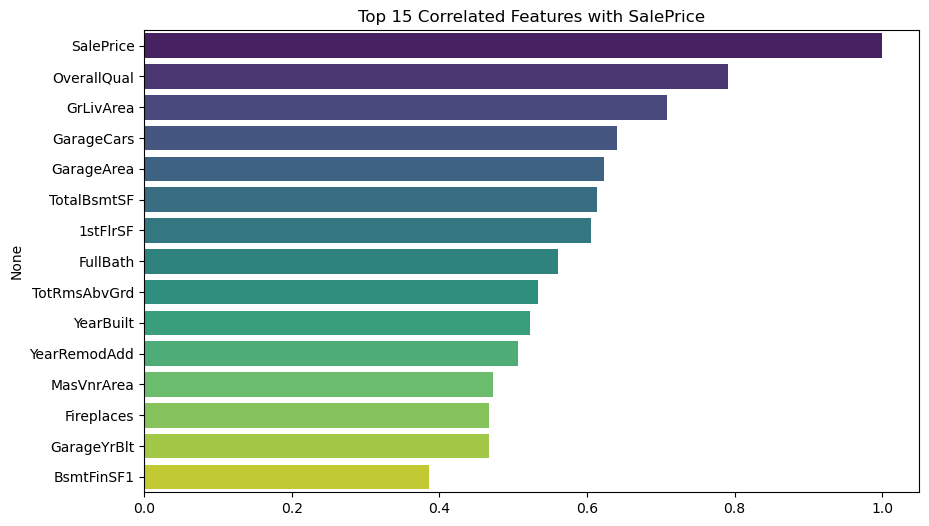

In [61]:
# Check correlation with target
corr = df_train_num.corr()["SalePrice"].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=corr.values[:15], y=corr.index[:15], palette="viridis")
plt.title("Top 15 Correlated Features with SalePrice")
plt.show()

In [62]:
import numpy as np

# Apply log transformation to reduce skewness
y = np.log1p(y)

In [63]:
import pandas as pd
import numpy as np

# Remove multicollinearity
corr_matrix = pd.DataFrame(X).corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

X = X.drop(columns=to_drop)

print("Dropped correlated features:", len(to_drop))

Dropped correlated features: 8


In [64]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score

# Ridge with automatic alpha tuning
ridge = RidgeCV(alphas=[1, 10, 50, 100, 200], cv=5)

ridge.fit(X, y)

print("Best alpha:", ridge.alpha_)

best_model = ridge
print("Selected Model: Ridge Regression")

Best alpha: 10
Selected Model: Ridge Regression


In [65]:
best_model = lr
print("Selected Model: Linear Regression")

Selected Model: Linear Regression


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_model.fit(X_train, y_train)

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# R2
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n🔍 Overfitting Check")
print("Train RMSE:", train_rmse)
print("Test RMSE :", test_rmse)
print("Train R2  :", train_r2)
print("Test R2   :", test_r2)


🔍 Overfitting Check
Train RMSE: 0.09225164101802594
Test RMSE : 0.2169716559892698
Train R2  : 0.9441732530484656
Test R2   : 0.7477281490298415


In [67]:
best_model.fit(X, y)

LinearRegression()

In [78]:
from sklearn.model_selection import cross_val_score

cv_rmse_scores = cross_val_score(
    best_model, X, y,
    scoring='neg_root_mean_squared_error',
    cv=5
)

cv_rmse = -cv_rmse_scores.mean()

rmse_percentage = (cv_rmse / y.mean()) * 100

target_met = rmse_percentage < 15

print(f"CV RMSE: {cv_rmse:.2f}")
print(f"RMSE % of Mean: {rmse_percentage:.2f}%")

if target_met:
    print("✅ Target Met: Model performance is good")
else:
    print("❌ Target Not Met: Model needs improvement")

CV RMSE: 0.18
RMSE % of Mean: 1.52%
✅ Target Met: Model performance is good


In [73]:
# Prepare final test dataset
final_test = pd.concat([df_test_num_scaled, df_test_cat_encoded], axis=1)
final_test = final_test[X.columns]  # ensure column order matches training data

predictions = np.expm1(best_model.predict(final_test))

In [74]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.coef_
})

# Use absolute values for importance
feature_importance['importance'] = feature_importance['importance'].abs()

feature_importance = feature_importance.sort_values('importance', ascending=False)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
              feature  importance
110  RoofMatl_Membran    3.170048
111    RoofMatl_Metal    3.027896
115  RoofMatl_WdShngl    2.829968
112     RoofMatl_Roll    2.798876
113  RoofMatl_Tar&Grv    2.782740
109  RoofMatl_CompShg    2.776198
114  RoofMatl_WdShake    2.711353
90    Condition2_PosN    0.840860
91    Condition2_RRAe    0.652548
108    RoofStyle_Shed    0.448138
36        MSZoning_FV    0.439234
208     GarageQual_Po    0.425350
212     GarageCond_Po    0.423535
38        MSZoning_RL    0.420867
37        MSZoning_RH    0.420697


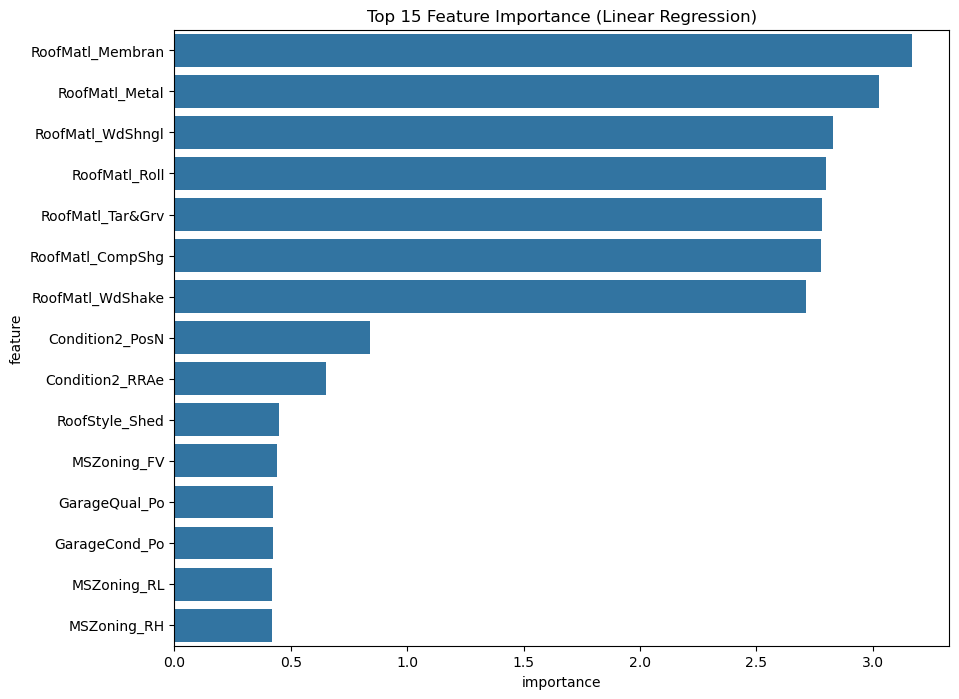

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(15),
    x='importance',
    y='feature'
)
plt.title('Top 15 Feature Importance (Linear Regression)')
plt.show()

In [76]:
import joblib
from datetime import datetime

# ✅ Select same 10 important numeric features
numeric_features = [
    "OverallQual", "GrLivArea", "TotalBsmtSF", "BsmtFinSF1",
    "GarageCars", "GarageArea", "TotRmsAbvGrd",
    "YearBuilt", "LotFrontage", "FullBath"
]

# ✅ Median values (for handling missing data later)
feature_medians = X[numeric_features].median().to_dict()

# ✅ Feature Importance for Linear Regression (using coefficients)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.coef_
})

# Take absolute values
feature_importance['importance'] = feature_importance['importance'].abs()
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Convert to dictionary
feature_importance_dict = feature_importance.to_dict()

# ✅ Create model artifact
model_artifacts = {
    "model": best_model,
    "model_name": "LinearRegression",

    "features": numeric_features,

    "training_date": datetime.now().strftime("%Y-%m-%d"),

    "performance_metrics": {
        "cv_rmse": round(cv_rmse, 2),
        "rmse_percentage": round(rmse_percentage, 2)
    },

    "target_met": target_met,

    "feature_medians": feature_medians,

    "feature_importance": feature_importance_dict,

    "scaler": scaler,

    "total_features": len(X.columns),

    "outlier_treatment_applied": True
}

# ✅ Save artifact
joblib.dump(model_artifacts, "linear_regression_house_price.pkl")

print("✅ Linear Regression model artifact saved successfully!")

✅ Linear Regression model artifact saved successfully!


In [77]:
# Load your saved model
loaded = joblib.load("linear_regression_house_price.pkl")

# Check what is inside
print(loaded.keys())

dict_keys(['model', 'model_name', 'features', 'training_date', 'performance_metrics', 'target_met', 'feature_medians', 'feature_importance', 'scaler', 'total_features', 'outlier_treatment_applied'])
